In [1]:
import qiskit
print(qiskit.__version__)

2.4.1


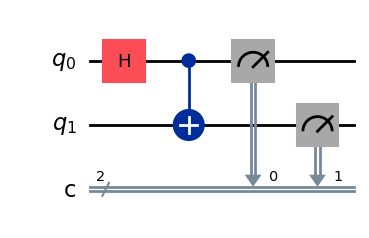

In [5]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
qc.measure([0,1],[0,1])
qc.draw('mpl')

{'00': 496, '11': 504}


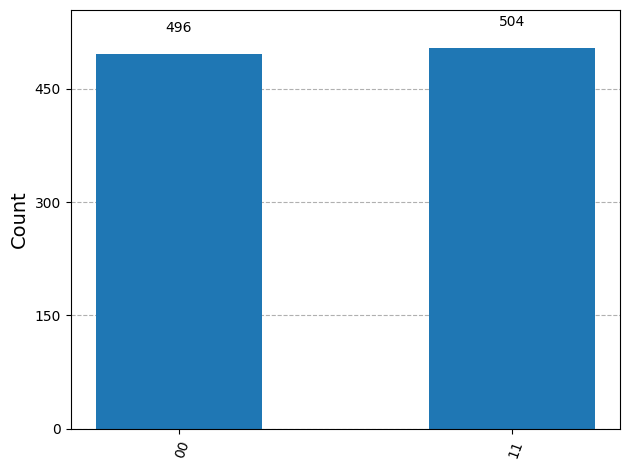

In [6]:
from qiskit import transpile

simulator = AerSimulator()
compiled = transpile(qc, simulator)
job = simulator.run(qc, shots=1000)
result = job.result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

In [ ]:
def bell_state(variant='phi_plus'):
    qc = QuantumCircuit(2, 2)
    if variant == 'phi_minus':
        qc.z(0)          
    elif variant == 'psi_plus':
        qc.x(1)          
    elif variant == 'psi_minus':
        qc.x(1); qc.z(0)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure([0,1],[0,1])
    return qc

phi_plus: {'00': 534, '11': 466}


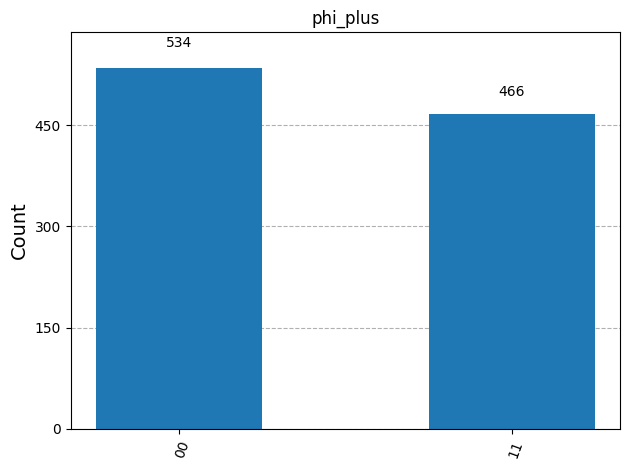

phi_minus: {'00': 499, '11': 501}


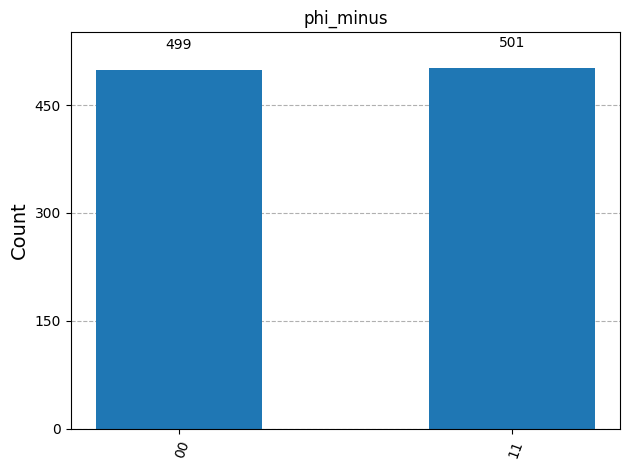

psi_plus: {'01': 491, '10': 509}


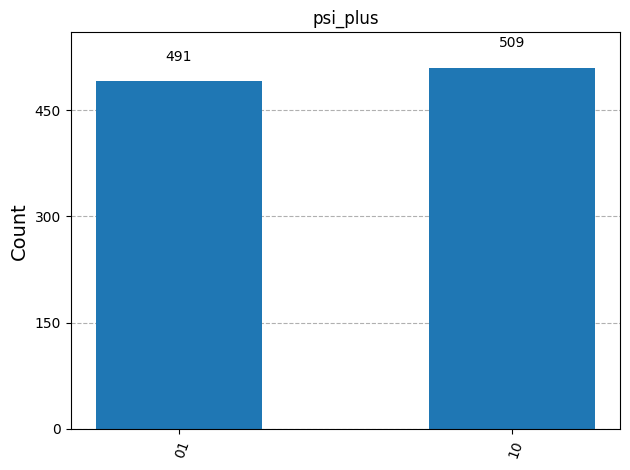

psi_minus: {'10': 483, '01': 517}


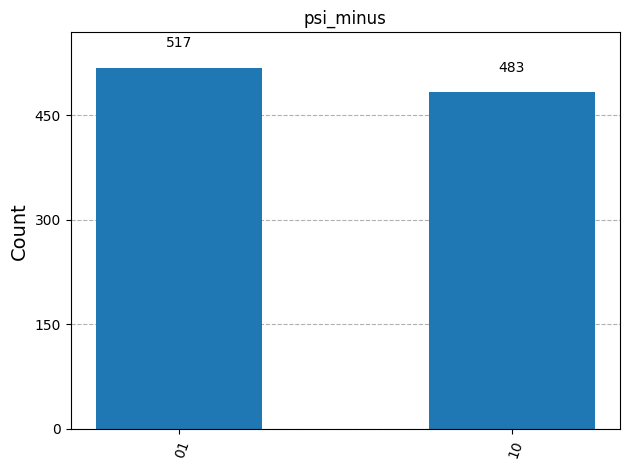

In [11]:
from IPython.display import display

for v in variants:
    qc = bell_state(v)
    compiled = transpile(qc, simulator)
    counts = simulator.run(compiled, shots=1000).result().get_counts()
    print(f"{v}: {counts}")
    fig = plot_histogram(counts, title=v)
    display(fig)
    plt.close()